# Statistical Experiments and Significance Testing

Notebook ini merangkum Chapter 3 dari *Practical Statistics for Data Scientists* edisi kedua. Chapter ini membahas rancangan eksperimen statistik, terutama **A/B testing**, **hypothesis testing**, **resampling**, **permutation test**, **statistical significance**, **p-value**, **t-test**, **multiple testing**, **ANOVA**, **chi-square test**, **multi-arm bandit**, serta **power dan sample size**.

Pembahasan dibuat mengikuti format notebook sebelumnya: terdapat tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, contoh kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami peran statistical experiments dalam data science.
- Menjelaskan prinsip A/B testing, treatment, control group, randomization, dan test statistic.
- Memahami null hypothesis, alternative hypothesis, serta perbedaan one-way dan two-way test.
- Menggunakan permutation test untuk mengevaluasi perbedaan antar grup.
- Menjelaskan statistical significance, p-value, alpha, Type I error, dan Type II error.
- Menggunakan t-test sebagai pendekatan klasik untuk membandingkan dua mean.
- Memahami risiko multiple testing, alpha inflation, dan false discovery rate.
- Memahami degrees of freedom sebagai jumlah nilai yang bebas bervariasi.
- Menggunakan ANOVA untuk membandingkan lebih dari dua grup.
- Menggunakan chi-square test untuk data kategori atau count data.
- Memahami multi-arm bandit sebagai pendekatan eksperimen yang lebih adaptif.
- Menjelaskan hubungan power, effect size, significance level, dan sample size.

## Ringkasan Chapter

Chapter ini menjelaskan bahwa design of experiments merupakan bagian penting dalam praktik statistik. Eksperimen dirancang untuk menguji hipotesis, misalnya apakah satu harga lebih menguntungkan daripada harga lain, atau apakah satu tampilan web menghasilkan lebih banyak klik dibanding tampilan lain.

Bagian awal chapter membahas A/B testing. A/B test membandingkan dua treatment, biasanya treatment baru dan control. Prinsip pentingnya adalah randomization, karena random assignment membuat perbedaan antar grup lebih mungkin disebabkan oleh treatment atau chance variation, bukan faktor luar yang sistematis.

Chapter kemudian membahas hypothesis testing. Null hypothesis menyatakan bahwa tidak ada efek khusus dan perbedaan yang diamati hanya akibat chance. Alternative hypothesis menyatakan kemungkinan yang ingin dibuktikan. One-way test digunakan ketika perhatian hanya pada satu arah efek, sedangkan two-way test digunakan ketika efek di kedua arah dianggap relevan.

Resampling dan permutation test digunakan untuk membangun null model dari data yang diamati. Data dari beberapa grup digabungkan, diacak, lalu dibagi ulang menjadi resample dengan ukuran yang sama seperti grup awal. Distribusi hasil resampling dibandingkan dengan statistic yang diamati untuk melihat apakah perbedaan tersebut masih wajar sebagai chance variation.

Bagian berikutnya membahas statistical significance dan p-value. P-value bukan probabilitas bahwa null hypothesis benar, tetapi probabilitas memperoleh hasil sama ekstrem atau lebih ekstrem daripada hasil observasi jika chance model berlaku. Chapter juga menekankan bahwa statistical significance tidak selalu berarti practical significance.

Chapter selanjutnya membahas t-test sebagai metode klasik sebelum resampling mudah dilakukan dengan komputer. Multiple testing dibahas sebagai risiko menemukan hasil signifikan secara kebetulan ketika banyak pengujian dilakukan. ANOVA digunakan untuk membandingkan lebih dari dua grup numeric, sedangkan chi-square test digunakan untuk count data. Bagian akhir memperkenalkan multi-arm bandit sebagai eksperimen adaptif dan power/sample size sebagai konsep untuk menentukan apakah eksperimen cukup besar untuk mendeteksi efek.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| A/B Testing | Eksperimen dua treatment untuk membandingkan hasil berdasarkan test statistic. |
| Hypothesis Tests | Kerangka null hypothesis dan alternative hypothesis untuk menilai chance variation. |
| Resampling | Pengambilan resample berulang dari data observasi untuk mengevaluasi random variability. |
| Permutation Test | Mengacak label grup untuk membentuk null distribution dari test statistic. |
| Statistical Significance and p-Values | Menilai apakah hasil eksperimen cukup ekstrem dibanding chance model. |
| t-Tests | Test klasik untuk membandingkan mean dua grup numeric. |
| Multiple Testing | Banyak pengujian meningkatkan risiko false positive atau alpha inflation. |
| Degrees of Freedom | Jumlah nilai yang bebas bervariasi dalam suatu perhitungan statistik. |
| ANOVA | Membandingkan lebih dari dua group means melalui variasi antar grup dan dalam grup. |
| Chi-Square Test | Menguji apakah count data konsisten dengan expected distribution atau independence. |
| Multi-Arm Bandit | Eksperimen adaptif yang mengalihkan lebih banyak traffic ke treatment yang lebih baik. |
| Power and Sample Size | Menentukan kemampuan eksperimen mendeteksi effect size tertentu. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(2024)

## A/B Testing

A/B testing adalah eksperimen dengan dua grup untuk menentukan treatment mana yang memberikan hasil lebih baik. Salah satu treatment biasanya merupakan treatment standar atau tanpa treatment, yang disebut control group.

Istilah penting dalam A/B testing:

| Istilah | Penjelasan |
|---|---|
| Treatment | Sesuatu yang diberikan atau ditampilkan kepada subject, misalnya harga, iklan, atau headline. |
| Treatment group | Grup yang menerima treatment tertentu. |
| Control group | Grup yang menerima treatment standar atau tidak menerima treatment baru. |
| Randomization | Proses menempatkan subject ke grup secara acak. |
| Subject | Unit yang menerima treatment, misalnya web visitor atau pasien. |
| Test statistic | Metric yang digunakan untuk mengukur efek treatment. |

Dalam konteks data science, A/B testing sering digunakan pada web design, product marketing, pricing, headline, atau iklan digital.

## Mengapa Control Group Penting?

Control group diperlukan agar terdapat pembanding yang mengalami kondisi sama dengan treatment group, kecuali pada treatment yang diuji. Tanpa control group, perbedaan hasil dapat berasal dari faktor lain di luar treatment.

Pada eksperimen web, subject biasanya adalah web visitor. Outcome yang diamati dapat berupa clicks, purchases, visit duration, number of pages visited, atau conversion. Metric utama perlu ditentukan sebelum eksperimen dilakukan agar tidak membuka peluang researcher bias.

In [2]:
# Contoh sederhana A/B test berbasis conversion
n_A = 1000
n_B = 1000

conversion_A = np.random.binomial(1, 0.08, n_A)
conversion_B = np.random.binomial(1, 0.10, n_B)

rate_A = conversion_A.mean()
rate_B = conversion_B.mean()

print("Conversion rate A:", round(rate_A, 4))
print("Conversion rate B:", round(rate_B, 4))
print("Observed difference:", round(rate_B - rate_A, 4))

Conversion rate A: 0.073
Conversion rate B: 0.115
Observed difference: 0.042


## Hypothesis Tests

Hypothesis test atau significance test digunakan untuk menilai apakah random chance dapat menjelaskan efek yang diamati. Dalam A/B test yang dirancang dengan benar, perbedaan antara grup A dan B dapat disebabkan oleh dua hal:

1. Perbedaan treatment yang benar-benar memiliki efek.
2. Chance variation akibat random assignment.

Hypothesis testing membantu melindungi analisis dari kecenderungan manusia yang sering melihat pola pada kejadian acak.

## Null dan Alternative Hypothesis

Null hypothesis adalah asumsi dasar bahwa tidak ada efek khusus, sehingga perbedaan yang diamati hanya akibat chance.

Alternative hypothesis adalah counterpoint dari null hypothesis, yaitu klaim yang ingin dibuktikan.

Contoh:

$$
H_0: p_A = p_B
$$

$$
H_1: p_A \ne p_B
$$

Keterangan:

- $H_0$ = null hypothesis
- $H_1$ = alternative hypothesis
- $p_A$ = conversion rate grup A
- $p_B$ = conversion rate grup B

Null dan alternative hypothesis harus mencakup seluruh kemungkinan.

## One-Way dan Two-Way Hypothesis Tests

One-way test digunakan ketika hanya satu arah efek yang dianggap penting. Misalnya, treatment B hanya akan dipilih jika terbukti lebih baik daripada treatment A.

Two-way test digunakan ketika efek di dua arah sama-sama relevan. Misalnya, treatment B dapat dianggap berbeda jika lebih baik atau lebih buruk dari A.

| Jenis Test | Fokus |
|---|---|
| One-way / one-tail | Extreme result hanya dihitung pada satu arah. |
| Two-way / two-tail | Extreme result dihitung pada dua arah. |

Chapter menekankan bahwa perbedaan one-tail dan two-tail sering membingungkan dan tidak terlalu sentral dalam praktik data science, karena p-value biasanya digunakan sebagai salah satu informasi, bukan satu-satunya dasar keputusan.

## Resampling

Resampling berarti mengambil sample berulang dari observed data untuk menilai random variability dari suatu statistic. Dua prosedur utama yang dibahas adalah:

| Metode | Tujuan |
|---|---|
| Bootstrap | Menilai reliabilitas suatu estimate. |
| Permutation test | Menguji hypothesis, biasanya untuk dua atau lebih grup. |

Bootstrap sudah dibahas pada chapter sebelumnya. Pada chapter ini, fokus resampling adalah permutation test.

## Permutation Test

Permutation test menguji null hypothesis dengan cara menggabungkan data dari semua grup, mengacaknya, lalu membagi ulang data tersebut ke dalam grup dengan ukuran yang sama seperti grup awal.

Langkah permutation test:

1. Gabungkan hasil dari grup yang berbeda ke satu dataset.
2. Shuffle data gabungan.
3. Ambil resample untuk grup A dengan ukuran yang sama seperti grup A awal.
4. Ambil resample untuk grup B dari sisa data dengan ukuran yang sama seperti grup B awal.
5. Hitung statistic yang sama seperti statistic observasi.
6. Ulangi proses tersebut banyak kali untuk membentuk permutation distribution.
7. Bandingkan observed statistic dengan permutation distribution.

Jika observed statistic berada dalam rentang umum permutation distribution, maka perbedaan yang diamati masih wajar sebagai chance variation.

In [3]:
# Contoh data session time Page A dan Page B
page_A = pd.Series([164, 172, 177, 156, 195, 90, 85, 105, 120, 80,
                    60, 75, 100, 110, 95, 130, 140, 70, 65, 115, 125])
page_B = pd.Series([178, 191, 182, 185, 177, 150, 160, 145, 170, 200,
                    135, 155, 140, 180, 165])

session_times = pd.DataFrame({
    "Page": ["Page A"] * len(page_A) + ["Page B"] * len(page_B),
    "Time": pd.concat([page_A, page_B], ignore_index=True)
})

mean_A = session_times[session_times["Page"] == "Page A"]["Time"].mean()
mean_B = session_times[session_times["Page"] == "Page B"]["Time"].mean()
observed_diff = mean_B - mean_A

print("Mean Page A:", round(mean_A, 2))
print("Mean Page B:", round(mean_B, 2))
print("Observed difference:", round(observed_diff, 2))

Mean Page A: 115.67
Mean Page B: 167.53
Observed difference: 51.87


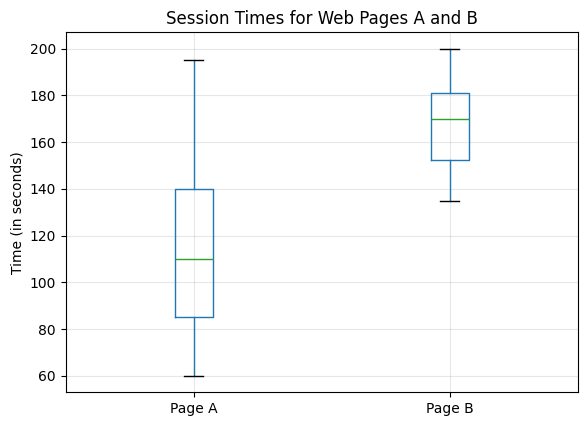

In [4]:
session_times.boxplot(by="Page", column="Time")
plt.xlabel("")
plt.ylabel("Time (in seconds)")
plt.title("Session Times for Web Pages A and B")
plt.suptitle("")
plt.grid(alpha=0.3)
plt.show()

## Fungsi Permutation Test

Fungsi berikut mengacak data gabungan, membagi ulang data menjadi grup A dan B, lalu menghitung selisih mean. Struktur ini mengikuti contoh web stickiness pada chapter.

In [5]:
def perm_fun(x, n_A, n_B):
    n = n_A + n_B
    idx_B = set(np.random.choice(range(n), n_B, replace=False))
    idx_A = set(range(n)) - idx_B

    idx_A = list(idx_A)
    idx_B = list(idx_B)

    return x.iloc[idx_B].mean() - x.iloc[idx_A].mean()

n_A = len(page_A)
n_B = len(page_B)

perm_diffs = pd.Series([
    perm_fun(session_times["Time"], n_A, n_B)
    for _ in range(1000)
])

p_value_perm = np.mean(perm_diffs > observed_diff)

print("Permutation p-value:", round(p_value_perm, 4))

Permutation p-value: 0.0


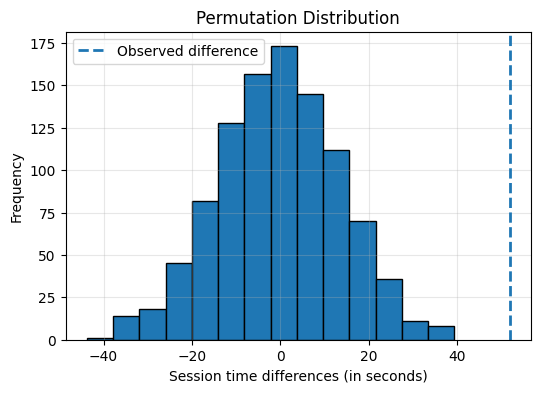

In [6]:
plt.figure(figsize=(6, 4))
plt.hist(perm_diffs, bins=14, edgecolor="black")
plt.axvline(observed_diff, linewidth=2, linestyle="--", label="Observed difference")
plt.xlabel("Session time differences (in seconds)")
plt.ylabel("Frequency")
plt.title("Permutation Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Exhaustive dan Bootstrap Permutation Tests

Chapter membedakan tiga variasi permutation test:

| Jenis | Penjelasan |
|---|---|
| Random permutation test | Data diacak sejumlah iterasi tertentu. |
| Exhaustive permutation test | Semua kemungkinan pembagian data dihitung; praktis hanya untuk sample kecil. |
| Bootstrap permutation test | Resampling dilakukan with replacement, bukan without replacement. |

Untuk data science, perbedaan teknis antar variasi tersebut tidak selalu menjadi fokus utama. Intinya, permutation test berguna karena mudah dijelaskan, fleksibel untuk data numeric maupun binary, dan tidak membutuhkan asumsi normal distribution.

## Statistical Significance and p-Values

Statistical significance digunakan untuk menilai apakah hasil eksperimen cukup ekstrem dibanding hasil yang mungkin muncul dari chance model. Jika hasil berada di luar rentang chance variation yang wajar, hasil tersebut disebut statistically significant.

P-value adalah probabilitas memperoleh hasil sama ekstrem atau lebih ekstrem daripada hasil observasi jika null model benar.

### Rumus Konseptual p-Value pada Permutation Test

$$
p =
\frac{
\#(\text{permutation statistic} \ge \text{observed statistic})
}{R}
$$

Keterangan:

- $p$ = p-value
- $R$ = jumlah permutation iterations
- observed statistic = statistic dari data asli
- permutation statistic = statistic dari data yang diacak ulang

## Contoh p-Value pada Conversion Rate

Chapter memberi contoh ecommerce experiment dengan data conversion dan no conversion untuk dua harga. Walaupun total data lebih dari 45.000, jumlah conversion hanya ratusan dan conversion rate kurang dari 1%. Karena itu, ukuran informasi yang benar-benar relevan adalah jumlah conversion, bukan hanya total exposure.

Contoh berikut mengikuti struktur tersebut untuk membentuk null model dari gabungan conversion.

In [7]:
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)

conversion = pd.Series([0] * 45945 + [1] * 382)

perm_diffs_conversion = pd.Series([
    100 * perm_fun(conversion, 23739, 22588)
    for _ in range(1000)
])

p_value_conversion = np.mean(perm_diffs_conversion > obs_pct_diff)

print(f"Observed difference: {obs_pct_diff:.4f}%")
print("Permutation p-value:", round(p_value_conversion, 4))

Observed difference: 0.0368%
Permutation p-value: 0.307


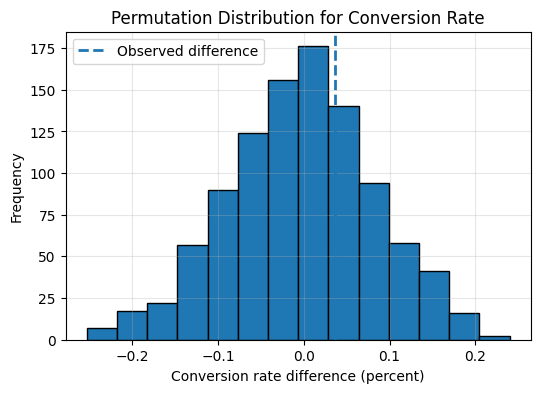

In [8]:
plt.figure(figsize=(6, 4))
plt.hist(perm_diffs_conversion, bins=14, edgecolor="black")
plt.axvline(obs_pct_diff, linewidth=2, linestyle="--", label="Observed difference")
plt.xlabel("Conversion rate difference (percent)")
plt.ylabel("Frequency")
plt.title("Permutation Distribution for Conversion Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Alpha, Practical Significance, dan Error Types

Alpha adalah threshold yang ditentukan sebelum pengujian, misalnya 0.05 atau 0.01. Jika p-value lebih kecil dari alpha, hasil sering dianggap statistically significant.

Namun, chapter menekankan beberapa hal penting:

- p-value bukan probabilitas bahwa null hypothesis benar.
- statistical significance tidak sama dengan practical significance.
- large sample dapat membuat efek kecil menjadi statistically significant tetapi tidak penting secara praktis.
- p-value sebaiknya menjadi salah satu informasi, bukan satu-satunya dasar keputusan.

Dua jenis error dalam significance testing:

| Error | Penjelasan |
|---|---|
| Type I error | Menyimpulkan efek nyata padahal hanya akibat chance. |
| Type II error | Menyimpulkan efek tidak nyata padahal efek sebenarnya ada. |

## t-Tests

t-test adalah significance test klasik untuk membandingkan mean dua grup numeric. Metode ini menjadi populer sebelum komputer memungkinkan resampling ribuan kali.

Dalam t-test, test statistic distandardisasi menjadi t-statistic, lalu dibandingkan dengan t-distribution. Chapter tidak menekankan formula manual karena software statistik sudah menyediakan implementasinya.

In [9]:
res = stats.ttest_ind(page_A, page_B, equal_var=False)

print("t-statistic:", round(res.statistic, 4))
print("two-sided p-value:", round(res.pvalue, 4))
print("one-sided p-value:", round(res.pvalue / 2, 4))

t-statistic: -5.1957
two-sided p-value: 0.0
one-sided p-value: 0.0


## Multiple Testing

Multiple testing terjadi ketika banyak hypothesis tests dilakukan pada data yang sama. Semakin banyak test yang dilakukan, semakin besar peluang mendapatkan hasil signifikan hanya karena chance.

Jika alpha = 0.05 dan dilakukan 20 test independen, probabilitas tidak ada false positive adalah:

$$
0.95^{20}
$$

Maka probabilitas minimal satu false positive adalah:

$$
1 - 0.95^{20}
$$

Fenomena meningkatnya peluang Type I error akibat banyak test disebut alpha inflation.

In [10]:
alpha = 0.05
n_tests = 20

prob_at_least_one_false_positive = 1 - (1 - alpha) ** n_tests

print("Probability of at least one false positive:")
print(round(prob_at_least_one_false_positive, 4))

Probability of at least one false positive:
0.6415


## Bonferroni Adjustment dan False Discovery Rate

Bonferroni adjustment adalah cara sederhana untuk mengurangi risiko false positive pada multiple testing.

### Rumus Bonferroni Adjustment

$$
\alpha_{\text{adjusted}} =
\frac{\alpha}{m}
$$

Keterangan:

- $\alpha$ = significance level awal
- $m$ = jumlah test
- $\alpha_{\text{adjusted}}$ = threshold baru untuk setiap test

False discovery rate mengacu pada proporsi discovery yang sebenarnya false positive. Dalam data science, isu multiple testing sering dikurangi dengan holdout set, cross-validation, resampling, dan simulation benchmarks.

In [11]:
alpha = 0.05
m = 20

adjusted_alpha = alpha / m

print("Original alpha:", alpha)
print("Bonferroni adjusted alpha:", adjusted_alpha)

Original alpha: 0.05
Bonferroni adjusted alpha: 0.0025


## Degrees of Freedom

Degrees of freedom adalah jumlah nilai yang bebas bervariasi dalam suatu perhitungan statistik. Konsep ini muncul dalam distribusi seperti t-distribution, chi-square distribution, dan F-distribution.

Contoh sederhana: jika tiga angka harus memiliki rata-rata tertentu, maka setelah dua angka dipilih bebas, angka ketiga sudah ditentukan. Dengan demikian, degrees of freedom-nya adalah 2.

Dalam praktik data science, degrees of freedom sering muncul sebagai parameter pada output software statistik.

## ANOVA

ANOVA atau analysis of variance digunakan untuk membandingkan lebih dari dua group means. Jika terdapat empat web page yang ingin dibandingkan, pairwise comparison menghasilkan banyak kombinasi dan meningkatkan risiko multiple testing. ANOVA menyediakan satu overall test untuk menilai apakah variasi antar group means lebih besar daripada yang wajar terjadi karena chance.

Chapter memberi contoh stickiness empat web pages yang diukur melalui session time.

In [12]:
page_data = pd.DataFrame({
    "Page 1": [164, 172, 177, 156, 195],
    "Page 2": [178, 191, 182, 185, 177],
    "Page 3": [175, 193, 171, 163, 176],
    "Page 4": [155, 166, 164, 170, 168]
})

page_data

,Page 1,Page 2,Page 3,Page 4
0,164,178,175,155
1,172,191,193,166
2,177,182,171,164
3,156,185,163,170
4,195,177,176,168


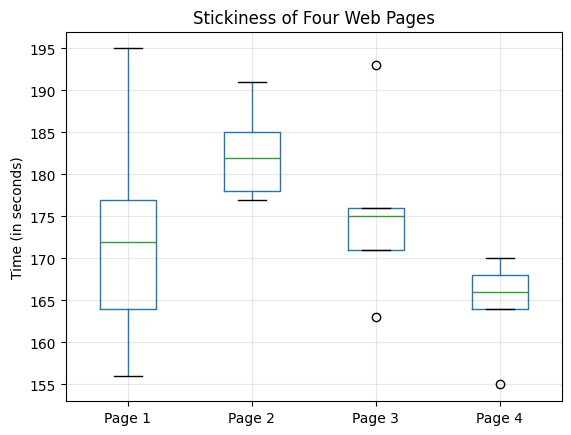

Group means:
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
dtype: float64

Grand average: 173.9


In [13]:
page_data.boxplot()
plt.ylabel("Time (in seconds)")
plt.title("Stickiness of Four Web Pages")
plt.grid(alpha=0.3)
plt.show()

print("Group means:")
print(page_data.mean())
print("\nGrand average:", round(page_data.values.flatten().mean(), 2))

## F-Statistic dalam ANOVA

F-statistic mengukur sejauh mana perbedaan antar group means melebihi variasi yang wajar terjadi di dalam masing-masing group.

### Rumus Konseptual F-Statistic

$$
F =
\frac{
\text{variability among group means}
}{
\text{variability within groups}
}
$$

Jika nilai F besar, maka perbedaan antar group means relatif besar dibanding variasi dalam group.

In [14]:
f_stat, p_value_anova = stats.f_oneway(
    page_data["Page 1"],
    page_data["Page 2"],
    page_data["Page 3"],
    page_data["Page 4"]
)

print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value_anova, 4))

F-statistic: 2.7398
p-value: 0.0776


## Two-Way ANOVA

Two-way ANOVA digunakan ketika terdapat dua faktor yang memengaruhi outcome. Contohnya, web stickiness dapat dipengaruhi oleh jenis page dan waktu kunjungan. Chapter menyebut two-way ANOVA sebagai perluasan dari ANOVA satu faktor.

Konsep utamanya adalah memisahkan variasi outcome berdasarkan dua faktor dan, jika diperlukan, interaksi antara keduanya.

## Chi-Square Test

Chi-square test digunakan untuk count data atau categorical data. Test ini menilai apakah observed counts konsisten dengan expected counts berdasarkan null model.

### Rumus Chi-Square Statistic

$$
\chi^2 =
\sum
\frac{
(O_i-E_i)^2
}{E_i}
$$

Keterangan:

- $O_i$ = observed count kategori ke-$i$
- $E_i$ = expected count kategori ke-$i$
- $\chi^2$ = chi-square statistic

Nilai chi-square kecil menunjukkan observed counts dekat dengan expected counts. Nilai besar menunjukkan penyimpangan yang lebih kuat dari null model.

In [15]:
# Contoh ecommerce conversion table dari chapter
conversion_table = np.array([
    [200, 23739 - 200],
    [182, 22588 - 182]
])

chi2, p_value_chi2, df, expected = stats.chi2_contingency(conversion_table)

print("Chi-square statistic:", round(chi2, 4))
print("p-value:", round(p_value_chi2, 4))
print("Degrees of freedom:", df)
print("\nExpected counts:")
print(np.round(expected, 2))

Chi-square statistic: 0.1489
p-value: 0.6996
Degrees of freedom: 1

Expected counts:
[[  195.75 23543.25]
 [  186.25 22401.75]]


## Chi-Square Test untuk Goodness-of-Fit

Chapter juga membahas contoh frekuensi digit dalam data laboratorium. Jika digit interior benar-benar acak, setiap digit 0–9 seharusnya muncul dengan frekuensi relatif seragam. Chi-square test dapat digunakan untuk mengevaluasi apakah observed counts terlalu jauh dari expected uniform distribution.

In [16]:
digit_counts = pd.Series(
    [14, 71, 7, 65, 23, 19, 12, 45, 53, 6],
    index=list(range(10))
)

expected_counts = np.repeat(digit_counts.sum() / 10, 10)

chi_square_digits = np.sum((digit_counts.values - expected_counts) ** 2 / expected_counts)
p_value_digits = 1 - stats.chi2.cdf(chi_square_digits, df=9)

print("Chi-square statistic:", round(chi_square_digits, 4))
print("p-value:", round(p_value_digits, 6))

Chi-square statistic: 174.3651
p-value: 0.0


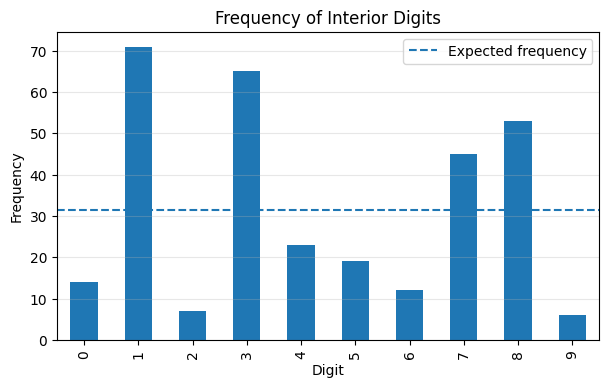

In [17]:
plt.figure(figsize=(7, 4))
digit_counts.plot(kind="bar")
plt.axhline(digit_counts.sum() / 10, linestyle="--", label="Expected frequency")
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Frequency of Interior Digits")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Fisher's Exact Test

Fisher's exact test digunakan untuk contingency table, terutama ketika count kecil dan pendekatan chi-square kurang tepat. Chapter menempatkan Fisher's exact test sebagai alternatif untuk kasus count data yang memerlukan hasil exact.

Dalam data science, chi-square test dan Fisher's exact test lebih sering digunakan sebagai alat untuk melihat apakah suatu efek atau feature layak dipertimbangkan lebih lanjut, bukan semata-mata sebagai formal test untuk publikasi ilmiah.

## Multi-Arm Bandit Algorithm

Multi-arm bandit adalah pendekatan eksperimen adaptif, terutama untuk web testing. Berbeda dari A/B test tradisional yang membagi traffic secara acak sampai eksperimen selesai, multi-arm bandit menggunakan informasi yang sudah terkumpul untuk mengalihkan lebih banyak traffic ke treatment yang tampak lebih baik.

Istilah penting:

| Istilah | Penjelasan |
|---|---|
| Multi-arm bandit | Analogi slot machine dengan beberapa arm dan payoff berbeda. |
| Arm | Treatment dalam eksperimen. |
| Win | Outcome sukses, misalnya click atau conversion. |

Pendekatan ini lebih fokus pada optimasi hasil daripada hanya membuktikan statistical significance.

## Epsilon-Greedy Algorithm

Salah satu algoritma sederhana untuk multi-arm bandit adalah epsilon-greedy.

Langkah konsepnya:

1. Generate angka acak antara 0 dan 1.
2. Jika angka tersebut lebih kecil dari epsilon, pilih treatment secara acak.
3. Jika angka tersebut lebih besar atau sama dengan epsilon, pilih treatment dengan response rate terbaik sejauh ini.

Jika epsilon = 1, prosesnya menjadi eksperimen acak standar. Jika epsilon = 0, prosesnya menjadi greedy penuh dan selalu memilih treatment terbaik sejauh ini.

In [18]:
true_rates = np.array([0.20, 0.04, 0.08])
epsilon = 0.1
n_rounds = 1000

wins = np.zeros(3)
pulls = np.zeros(3)

for t in range(n_rounds):
    if np.random.rand() < epsilon or np.any(pulls == 0):
        arm = np.random.choice(3)
    else:
        arm = np.argmax(wins / pulls)

    reward = np.random.rand() < true_rates[arm]
    pulls[arm] += 1
    wins[arm] += reward

results = pd.DataFrame({
    "Arm": ["A", "B", "C"],
    "Pulls": pulls.astype(int),
    "Wins": wins.astype(int),
    "Observed response rate": np.round(wins / pulls, 3)
})

results

,Arm,Pulls,Wins,Observed response rate
0,A,930,189,0.203
1,B,36,1,0.028
2,C,34,2,0.059


## Power and Sample Size

Power adalah probabilitas bahwa suatu test akan mendeteksi effect size tertentu ketika efek tersebut benar-benar ada. Sample size, effect size, dan significance level saling berkaitan.

Istilah penting:

| Istilah | Penjelasan |
|---|---|
| Effect size | Besar efek minimum yang ingin dideteksi, misalnya peningkatan click rate 20%. |
| Power | Probabilitas mendeteksi effect size tertentu dengan sample size tertentu. |
| Significance level | Threshold statistical significance, misalnya 0.05. |

Chapter menekankan bahwa tidak ada aturan umum seperti “jalankan A/B test satu minggu” yang selalu valid. Sample size bergantung pada baseline rate, effect size yang ingin dideteksi, dan tingkat kepastian yang dibutuhkan.

In [19]:
# Ilustrasi: semakin kecil effect size, semakin besar sample size yang dibutuhkan
effect_sizes = np.array([0.01, 0.02, 0.05, 0.10, 0.20])
relative_sample_size = 1 / effect_sizes**2

sample_size_table = pd.DataFrame({
    "Effect size": effect_sizes,
    "Relative sample size needed": relative_sample_size.astype(int)
})

sample_size_table

,Effect size,Relative sample size needed
0,0.01,10000
1,0.02,2500
2,0.05,399
3,0.10,99
4,0.20,24


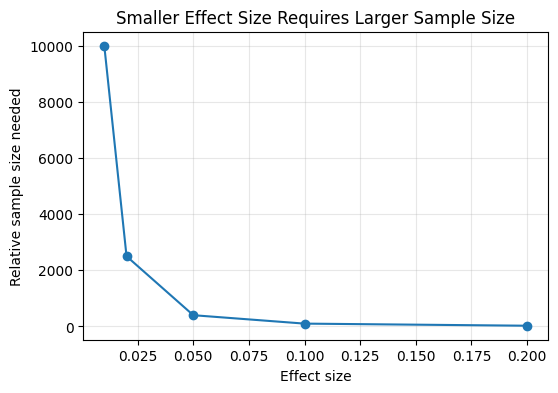

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(effect_sizes, relative_sample_size, marker="o")
plt.xlabel("Effect size")
plt.ylabel("Relative sample size needed")
plt.title("Smaller Effect Size Requires Larger Sample Size")
plt.grid(alpha=0.3)
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| A/B testing | Eksperimen dua treatment untuk membandingkan hasil. |
| Control group | Grup pembanding yang menerima treatment standar atau tidak menerima treatment baru. |
| Randomization | Penempatan subject ke grup secara acak untuk mengurangi bias. |
| Test statistic | Metric utama yang digunakan untuk membandingkan grup. |
| Null hypothesis | Asumsi bahwa tidak ada efek khusus dan perbedaan terjadi karena chance. |
| Alternative hypothesis | Klaim tandingan terhadap null hypothesis. |
| One-way test | Test yang menghitung extreme result hanya pada satu arah. |
| Two-way test | Test yang menghitung extreme result pada dua arah. |
| Resampling | Pengambilan resample berulang dari observed data. |
| Permutation test | Mengacak label grup untuk membentuk null distribution. |
| Statistical significance | Kondisi ketika hasil dianggap terlalu ekstrem untuk dijelaskan oleh chance model. |
| p-value | Probabilitas hasil sama ekstrem atau lebih ekstrem jika null model berlaku. |
| Alpha | Threshold untuk menentukan statistical significance. |
| Type I error | Menganggap efek nyata padahal hanya chance. |
| Type II error | Menganggap efek tidak nyata padahal efek sebenarnya ada. |
| t-test | Test klasik untuk membandingkan dua mean numeric. |
| Multiple testing | Banyak test meningkatkan risiko false positive. |
| Bonferroni adjustment | Membagi alpha dengan jumlah test. |
| Degrees of freedom | Jumlah nilai yang bebas bervariasi dalam perhitungan statistik. |
| ANOVA | Test untuk membandingkan lebih dari dua group means. |
| Chi-square test | Test untuk count data atau categorical data. |
| Multi-arm bandit | Eksperimen adaptif yang mengalokasikan traffic berdasarkan hasil sementara. |
| Power | Probabilitas mendeteksi effect size yang benar-benar ada. |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa eksperimen statistik bertujuan membantu pengambilan keputusan berdasarkan data, tetapi hasil eksperimen harus selalu dipisahkan dari chance variation. A/B testing menjadi contoh utama karena membandingkan dua treatment dengan control group, randomization, dan test statistic yang ditentukan sejak awal.

Hypothesis testing menyediakan kerangka untuk mengevaluasi apakah perbedaan yang diamati masih wajar sebagai random variation. Null hypothesis menjadi model dasar bahwa tidak ada efek khusus, sedangkan alternative hypothesis menyatakan kemungkinan efek yang ingin diuji.

Permutation test menjadi pendekatan yang sangat relevan untuk data science karena fleksibel, mudah dijelaskan, dan tidak membutuhkan asumsi distribusi normal. Observed statistic dibandingkan dengan permutation distribution untuk menilai apakah hasil eksperimen cukup ekstrem.

P-value dan statistical significance perlu ditafsirkan hati-hati. P-value bukan probabilitas bahwa null hypothesis benar, dan hasil yang statistically significant belum tentu practically significant. Dalam data science, p-value lebih tepat dilihat sebagai salah satu informasi pendukung, bukan penentu keputusan tunggal.

Chapter ini juga membahas beberapa metode lanjutan. t-test adalah pendekatan klasik untuk membandingkan dua mean. Multiple testing meningkatkan risiko false positive. ANOVA digunakan untuk membandingkan banyak group means, sedangkan chi-square test digunakan untuk count data. Multi-arm bandit memperkenalkan eksperimen adaptif yang lebih berorientasi optimasi, dan power/sample size menjelaskan kebutuhan data agar eksperimen mampu mendeteksi efek yang relevan.